# Random Forest


<b> Objective: </b>
Conduct Experiments with Random Forest

----------------------

<i><b>Author: </b> Salvador Palma <br>
<b>Institution: </b> Copenhagen University </i>


### Imports

In [1]:
import sys
COLAB_SESSION = False

if COLAB_SESSION:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_PATH = "/content/drive/MyDrive/UCPH/POOCS/"
    sys.path.insert(0, DRIVE_PATH)      # so GreenlandUtils.py is importable
else:
    DRIVE_PATH = ""
    
import pandas as pd
from sklearn.ensemble import  RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_absolute_error
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
from GreenlandUtils import lonlatToUTM24N, Split, verifyStratification, displaySplit, MostCommonElements

### Setup

In [2]:
DATA_TYPE = "Whole Rock"
MERGE_TYPE = "Mean Merge"
metaCols = ['Sample number', 'Sampling year', 'Rock description', 'Link to report', 'Collector', 'Batch', 'Longitude', 'Latitude', 'Laboratory', 'Treatment year', 'Sample preparation abbr', 'Analytical method abbr']


def ReadSplit(path: str, baseName: str, df: pd.DataFrame) -> Split:
    with open(f"{DRIVE_PATH}{path}{baseName}.json", "r") as f:
        json_result = json.load(f)
        
    return Split({name: df.iloc[idx] for name, idx in json_result.items()})


def ReadKFold(path: str, baseName: str, df: pd.DataFrame) -> list[Split]:
    splits = []
    i = 1
    while True:
        try:
            split = ReadSplit(path, f"{baseName}-{i}", df)
            splits.append(split)
            i += 1
        except FileNotFoundError:
            break
    return splits

def ReadDataFrame(path: str, baseName: str) -> pd.DataFrame:
    return pd.read_csv(f"{DRIVE_PATH}{path}{baseName}.csv", delimiter=";")

def ReadNearestNeighbours(path: str, baseName: str) -> dict[int, list[int]]:
    with open(f"{DRIVE_PATH}{path}{baseName}.json", "r") as f:
        json_result = json.load(f)
    return {int(k): v for k, v in json_result.items()}


df = ReadDataFrame(f"Data/{DATA_TYPE}/{MERGE_TYPE}/", "Data")
split = ReadSplit(f"Data/{DATA_TYPE}/{MERGE_TYPE}/", "Splits", df)
kfold_splits = ReadKFold(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Folds/", "Split", df)
nns = ReadNearestNeighbours(f"Data/{DATA_TYPE}/{MERGE_TYPE}/", "NearestNeighbours")

In [3]:
print(len(df))
print(len(split.data))
print(len(split.data["train"]))
print(len(split.data["test"]))
print(len(kfold_splits))
print(len(nns))
print(len(nns[0]))

6957
3
5565
696
5
6957
20


In [4]:
def ValidateKFold(kfold_splits: list[Split], df: pd.DataFrame):
    test_sets = [set(s.data["test"].index) for s in kfold_splits]

    print("test sizes:", [len(t) for t in test_sets])
    print("union:", len(set().union(*test_sets)), "of", len(df))
    print("pairwise overlaps:", [len(a & b) for i, a in enumerate(test_sets)
                                            for b in test_sets[i+1:]])

    for i, s in enumerate(kfold_splits):
        tr, te = set(s.data["train"].index), set(s.data["test"].index)
        print(f"fold {i}: train {len(tr)}, test {len(te)}, leak {len(tr & te)}")
        
        
ValidateKFold(kfold_splits, df)

test sizes: [1392, 1392, 1391, 1391, 1391]
union: 6957 of 6957
pairwise overlaps: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
fold 0: train 5565, test 1392, leak 0
fold 1: train 5565, test 1392, leak 0
fold 2: train 5566, test 1391, leak 0
fold 3: train 5566, test 1391, leak 0
fold 4: train 5566, test 1391, leak 0


### Naive Random Forest

In [5]:
print(MostCommonElements(df, [col for col in df.columns if col not in metaCols], top_n=10))

Analyzing Elements: 100%|██████████| 76/76 [00:00<00:00, 7592.77it/s]

[('CaO wt%', np.int64(6580)), ('MnO wt%', np.int64(6362)), ('TiO2 wt%', np.int64(6309)), ('K2O wt%', np.int64(6221)), ('Na2O wt%', np.int64(5993)), ('Zn ppm', np.int64(5947)), ('Sr ppm', np.int64(5591)), ('Al2O3 wt%', np.int64(5563)), ('MgO wt%', np.int64(5545)), ('Ni ppm', np.int64(5526))]


In [6]:
def ArrangeData(df: pd.DataFrame, element: str, elementCols: list[str]):
    df = df.copy()
    df = df.dropna(subset=[element])
    X = df[elementCols].copy()
    y = df[element].copy()
    X = X.drop(columns=[element], errors='ignore')

    return X, y

def TrainRandomForest(df_train: pd.DataFrame, df_test: pd.DataFrame, element: str, elementCols: list[str], n_jobs:int=-1):
    X_train, y_train = ArrangeData(df_train, element, elementCols)
    X_test, y_test = ArrangeData(df_test, element, elementCols)

    if X_train.empty or X_test.empty:
        return { "r2": None, "mae": None }
    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=n_jobs)
    model.fit(X_train, y_train)
    
    r2 = model.score(X_test, y_test)
    
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)

    return { "r2": r2, "mae": mae, "y_pred": y_pred, "y_test": y_test }



train, test = split.data["train"], split.data["test"]

elementCols = [col for col in train.columns if col not in metaCols]

score = TrainRandomForest(train, test, element="CaO wt%", elementCols=elementCols)

print(f"R2 Score: {score['r2']:.4f}")
print(f"MAE: {score['mae']:.4f}")


R2 Score: 0.7967
MAE: 0.1641


In [7]:
from joblib import Parallel, delayed


def TrainAllElements(split: Split, elementsToTrain: list[str], elementCols: list[str]=elementCols, n_jobs: int=-1, preTransform:callable=None, postTransform:callable=None, **kwargs):

    train, test = split.data["train"], split.data["test"]

    scores = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(TrainRandomForest)(train, test, element, elementCols, n_jobs=1)
        for element in elementsToTrain
    )

    return dict(zip(elementsToTrain, scores))

def TrainAllElementsKFold(kfold_splits: list[Split], elementsToTrain: list[str], elementCols: list[str]=elementCols, n_jobs: int=-1, **kwargs):

    jobs = [
        (element, foldIdx, split)
        for element in elementsToTrain
        for foldIdx, split in enumerate(kfold_splits)
    ]

    scores = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(TrainRandomForest)(
            split.data["train"], split.data["test"], element, elementCols, n_jobs=1
        )
        for element, foldIdx, split in jobs
    )

    results = {element: {} for element in elementsToTrain}
    for (element, foldIdx, _), score in zip(jobs, scores):
        results[element][foldIdx] = score

    return results

mostCommonElements = MostCommonElements(df, elementCols, top_n=10)
mostCommonElements = [element for element, _ in mostCommonElements]
results = TrainAllElements(split, mostCommonElements, n_jobs=-1) 
results_kfold = TrainAllElementsKFold(kfold_splits, mostCommonElements, n_jobs=-1)

Analyzing Elements: 100%|██████████| 76/76 [00:00<00:00, 4462.59it/s]
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   59.7s remaining:  2.3min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:  1.1min remaining:  1.1min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  1.1min remaining:   28.6s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   57.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done  41 out of  50 | elapsed:  5.6min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:  5.9min remaining: 

In [8]:
import numpy as np 

def SaveResults(results: dict, path: str, baseName: str):
    for _, score in results.items():
        if "y_pred" in score:
            score["y_pred"] = score["y_pred"].tolist() if not isinstance(score["y_pred"], list) else score["y_pred"]
        if "y_test" in score:
            score["y_test"] = score["y_test"].tolist() if not isinstance(score["y_test"], list) else score["y_test"]
    
    with open(f"{DRIVE_PATH}{path}{baseName}.json", "w") as f:
        json.dump(results, f, indent=4)

def AggregateFolds(kfoldResults: dict):
    aggregated = {}

    for element, folds in kfoldResults.items():
        valid = [s for s in folds.values() if s["r2"] is not None and not np.isnan(s["r2"])]
        if not valid:
            aggregated[element] = { "r2": None, "mae": None }
            continue

        aggregated[element] = {
            "r2": float(np.mean([s["r2"] for s in valid])),
            "r2_std": float(np.std([s["r2"] for s in valid])),
            "mae": float(np.mean([s["mae"] for s in valid])),
            "y_pred": np.concatenate([s["y_pred"] for s in valid]),
            "y_test": np.concatenate([s["y_test"] for s in valid]),
        }

    return aggregated
        
SaveResults(results, f"Results/", "RandomForest")
SaveResults(AggregateFolds(results_kfold), f"Results/", "RandomForest_KFold")

In [9]:

from GreenlandUtils import Printable
import numpy as np 


def PooledR2Log(results: dict):
    ss_res, ss_tot = 0.0, 0.0
    
    for score in results.values():
        if score["r2"] is None or "y_test" not in score:
            continue
        
        y_test = np.asarray(score["y_test"], dtype=float)
        y_pred = np.asarray(score["y_pred"], dtype=float)
        
        #Log10 scale so wt%/ppm/ppb elements contribute comparably (drop BDL zeros)
        valid = (y_test > 0) & (y_pred > 0)
        if valid.sum() < 2:
            continue
        
        y_test_log = y_test[valid]
        y_pred_log = y_pred[valid]
        
        ss_res += ((y_test_log - y_pred_log) ** 2).sum()
        ss_tot += ((y_test_log - y_test_log.mean()) ** 2).sum()
        
    return 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

def GlobalScores(printable: Printable, results: dict):
    valid_r2 = [s["r2"] for s in results.values() if s["r2"] is not None and not np.isnan(s["r2"])]
    
    printable.add("Mean R2 Score", f"{np.mean(valid_r2):.4f}")
    printable.add("Median R2 Score", f"{np.median(valid_r2):.4f}")
    printable.add("Pooled R2 Score (log10)", f"{PooledR2Log(results):.4f}")

def ReportResults(results: dict):
    printable = Printable()
    printable.title("Element Scores")
    for element, score in results.items():
        if score["r2"] is None:
            continue

        r2 = f"R2: {score['r2']:>8.4f}"
        #r2_std only exists for k-fold results, so pad single-split rows to match
        if "r2_std" in score:
            r2 += f" ± {score['r2_std']:.4f}"
        else:
            r2 += " " * 9

        printable.add(element, f"{r2}   MAE: {score['mae']:.4f}")
      
    printable.rest()
    printable.title("Global Score")

    GlobalScores(printable, results)

    # printable.rest()
    # printable.title("Global Score Top 10 Elements")


    # top_10_results = {element: score for element, score in results.items() if element in mostCommonElements}

    # GlobalScores(printable, top_10_results)

    printable.pretty()
    
ReportResults(results)

ReportResults(AggregateFolds(results_kfold))

======================= Element Scores =======================
CaO wt%:                   R2:   0.7967            MAE: 0.1641
MnO wt%:                   R2:   0.8034            MAE: 0.1394
TiO2 wt%:                  R2:   0.8395            MAE: 0.1290
K2O wt%:                   R2:   0.8395            MAE: 0.1810
Na2O wt%:                  R2:   0.8131            MAE: 0.1751
Zn ppm:                    R2:   0.6920            MAE: 0.1681
Sr ppm:                    R2:   0.8175            MAE: 0.1871
Al2O3 wt%:                 R2:   0.8919            MAE: 0.0745
MgO wt%:                   R2:   0.9032            MAE: 0.1338
Ni ppm:                    R2:   0.8296            MAE: 0.2101


======================== Global Score ========================
Mean R2 Score:             0.8226
Median R2 Score:           0.8236
Pooled R2 Score (log10):   0.7796
======================= Element Scores =======================
CaO wt%:                   R2:   0.8127 ± 0.0067   MAE: 0.1517
MnO wt%:      

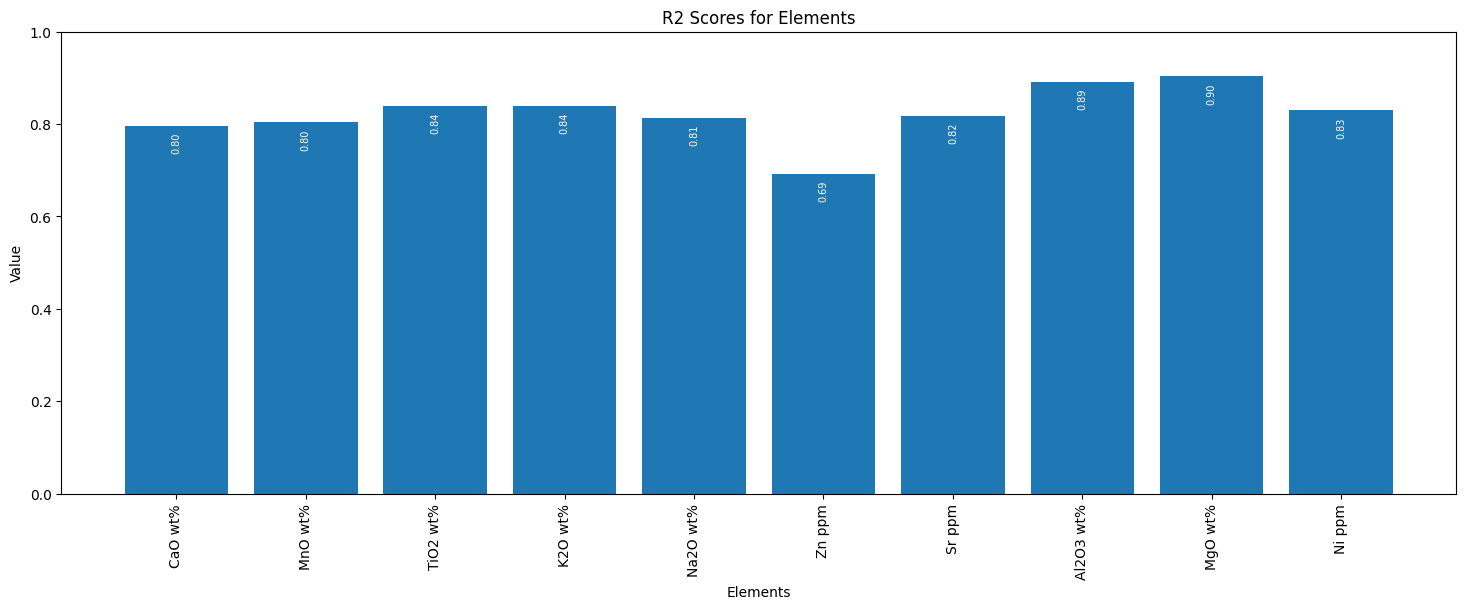

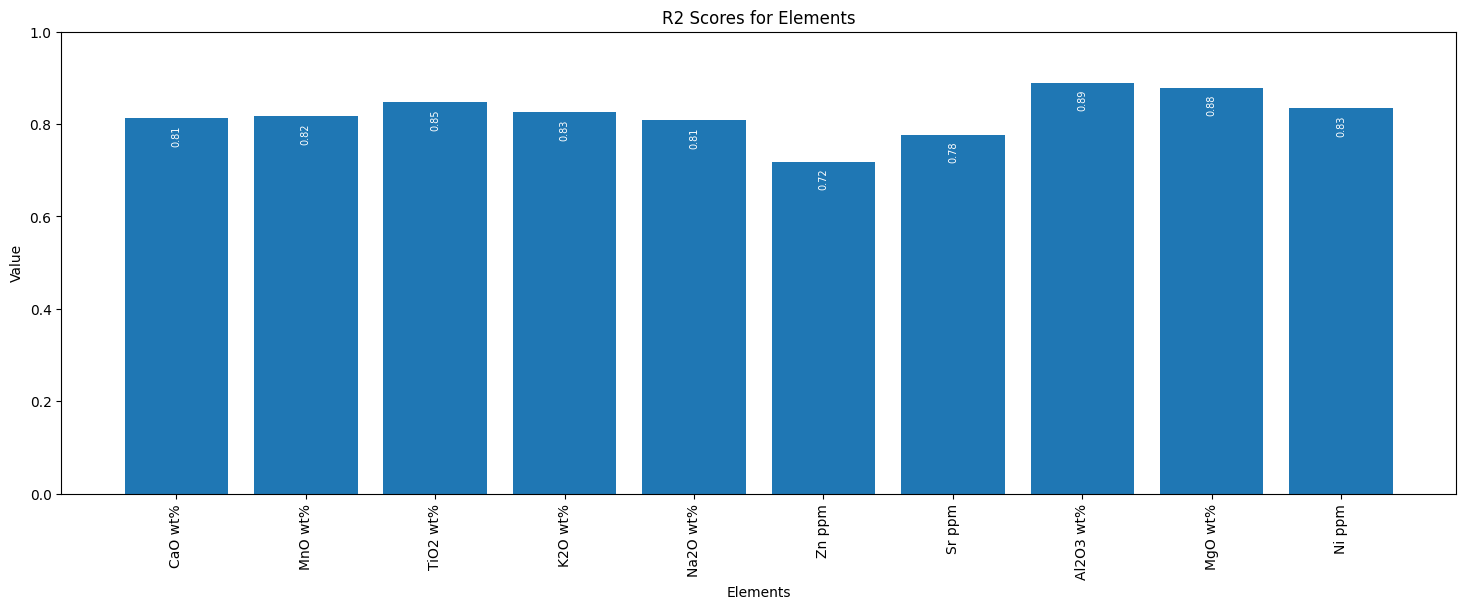

In [10]:
def DisplayElementScores(elementScores: dict):
    scores_df = pd.DataFrame.from_dict(elementScores, orient='index')
    #scores_df = scores_df.sort_values(by='r2', ascending=False)
    scores_df = scores_df[['r2', 'mae']]
    display(scores_df)
    
def DisplayElementScoresGraph(elementScores:dict, metric="r2", title="Element Scores"):
    
    scores = []
    for element, score in elementScores.items():
        if score[metric] is not None:
            scores.append((element, score[metric]))
    
    labels, values = zip(*scores)
    

    plt.figure(figsize=(18, 6))
    bars = plt.bar(labels, values)
    plt.bar_label(bars, fmt="%.2f", padding=-20, rotation=90, fontsize=7, color="white")
    plt.ylim(0, 1)
    plt.xlabel("Elements")
    plt.ylabel("Value")
    plt.xticks(rotation=90)
    plt.title(title)

    plt.show()

#DisplayElementScores(results)
DisplayElementScoresGraph(results, metric="r2", title="R2 Scores for Elements")
DisplayElementScoresGraph(AggregateFolds(results_kfold), metric="r2", title="R2 Scores for Elements")



### Random Forest + K Nearest Neighbours 

In [11]:
from GreenlandUtils import lonlatToUTM24N


nns_df : dict[int, pd.DataFrame] = {i: ReadDataFrame(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Folds/", f"Data_KNN_Fold_{i+1}") for i in range(len(kfold_splits))}
nns_splits : list[Split]= [ReadSplit(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Folds/", f"Split-{i+1}", nns_df[i]) for i, df in nns_df.items()]


In [22]:
#Mean target
def CreateKNNMask_A(df: pd.DataFrame, elementCols: list[str], element: str, knn:int):
    result = elementCols + [f"{knn}-KNN_{element}_mean"]
    for col in result:
        if col not in df.columns:
            print(f"Column {col} not found in DataFrame") 
    return result

#Individual target values
def CreateKNNMask_B(df: pd.DataFrame, elementCols: list[str], element: str, knn:int):
    result = elementCols + [f"{i+1}of{knn}-KNN_{element}" for i in range(knn)]
    for col in result:
        if col not in df.columns:
            print(f"Column {col} not found in DataFrame") 
    return result

#All means
def CreateKNNMask_C(df: pd.DataFrame, elementCols: list[str], element: str, knn:int):
    result = elementCols + [f"{knn}-KNN_{e}_mean" for e in elementCols]
    for col in result:
        if col not in df.columns:
            print(f"Column {col} not found in DataFrame") 
    return result
    
#All individual values
def CreateKNNMask_D(df: pd.DataFrame, elementCols: list[str], element: str, knn:int):
    result = elementCols + [f"{i+1}of{knn}-KNN_{e}" for e in elementCols for i in range(knn)]
    for col in result:
        if col not in df.columns:
            print(f"Column {col} not found in DataFrame") 
    return result

def ApplyMask(split: Split, maskFunction: callable, elementCols: list[str], element: str, knn:int):
    train, test = split.data["train"], split.data["test"]

    train_masked = train[maskFunction(train, elementCols, element, knn)]
    test_masked = test[maskFunction(test, elementCols, element, knn)]

    return Split({"train": train_masked, "test": test_masked})

print(f"Original Elements: {len(elementCols)}")

print(nns_splits[0].data["train"].columns.to_list())
print(len(nns_splits[0].data["train"].columns))

print(CreateKNNMask_A(nns_splits[0].data["train"], elementCols, "CaO wt%", 5))
print(len(CreateKNNMask_A(nns_splits[0].data["train"], elementCols, "CaO wt%", 5)))
print(CreateKNNMask_B(nns_splits[0].data["train"], elementCols, "CaO wt%", 5))
print(len(CreateKNNMask_B(nns_splits[0].data["train"], elementCols, "CaO wt%", 5)))
print(CreateKNNMask_C(nns_splits[0].data["train"], elementCols, "CaO wt%", 5))
print(len(CreateKNNMask_C(nns_splits[0].data["train"], elementCols, "CaO wt%", 5)))
print(CreateKNNMask_D(nns_splits[0].data["train"], elementCols, "CaO wt%", 5))
print(len(CreateKNNMask_D(nns_splits[0].data["train"], elementCols, "CaO wt%", 5)))

Original Elements: 76
['Sample number', 'Sampling year', 'Rock description', 'Link to report', 'Collector', 'Batch', 'Longitude', 'Latitude', 'Laboratory', 'Treatment year', 'Sample preparation abbr', 'Analytical method abbr', 'SiO2 wt%', 'TiO2 wt%', 'Al2O3 wt%', 'Fe2O3 wt%', 'Fe2O3 wt%.1', 'FeO wt%', 'MnO wt%', 'MgO wt%', 'CaO wt%', 'Na2O wt%', 'K2O wt%', 'P2O5 wt%', 'C wt%', 'Li ppm', 'Be ppm', 'B ppm', 'S ppm', 'Cl wt%', 'Sc ppm', 'V ppm', 'Cr ppm', 'Co ppm', 'Ni ppm', 'Cu ppm', 'Zn ppm', 'Ga ppm', 'Ge ppm', 'As ppm', 'Se ppm', 'Br ppm', 'Rb ppm', 'Sr ppm', 'Y ppm', 'Zr ppm', 'Nb ppm', 'Mo ppm', 'Ru ppb', 'Rh ppb', 'Pd ppb', 'Ag ppm', 'Cd ppm', 'In ppm', 'Sn ppm', 'Sb ppm', 'Te ppm', 'I ppm', 'Cs ppm', 'Ba ppm', 'La ppm', 'Ce ppm', 'Pr ppm', 'Nd ppm', 'Sm ppm', 'Eu ppm', 'Gd ppm', 'Tb ppm', 'Dy ppm', 'Ho ppm', 'Er ppm', 'Tm ppm', 'Yb ppm', 'Lu ppm', 'Hf ppm', 'Ta ppm', 'W ppm', 'Re ppb', 'Os ppb', 'Ir ppb', 'Pt ppb', 'Au ppb', 'Hg ppm', 'Tl ppm', 'Pb ppm', 'Bi ppm', 'Th ppm', 'U ppm

In [29]:
from joblib import Parallel, delayed


def TrainAllElementsKFoldKNN(nns_splits: list[Split], elementsToTrain: list[str], elementCols: list[str]=elementCols, n_jobs: int=-1, knn:int=5, maskFunction: callable=CreateKNNMask_A, **kwargs):

    

    jobs = [
        (element, foldIdx, split)
        for element in elementsToTrain
        for foldIdx, split in enumerate(nns_splits)
    ]

    scores = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(TrainRandomForest)(
            ApplyMask(split, maskFunction, elementCols, element, knn).data["train"],
            ApplyMask(split, maskFunction, elementCols, element, knn).data["test"],
            element, 
            maskFunction(split.data["train"], elementCols, element, knn),
            n_jobs=1
        )
        for element, foldIdx, split in jobs
    )

    results = {element: {} for element in elementsToTrain}
    for (element, foldIdx, _), score in zip(jobs, scores):
        results[element][foldIdx] = score

    return results

mostCommonElements = MostCommonElements(df, elementCols, top_n=10)
mostCommonElements = [element for element, _ in mostCommonElements]

results_kfold_knn_A = TrainAllElementsKFoldKNN(nns_splits, mostCommonElements, elementCols, n_jobs=-1, knn=5, maskFunction=CreateKNNMask_A)
SaveResults(AggregateFolds(results_kfold_knn_A), f"Results/", "RandomForest_KFold_KNN_A")

results_kfold_knn_B = TrainAllElementsKFoldKNN(nns_splits, mostCommonElements, elementCols, n_jobs=-1, knn=5, maskFunction=CreateKNNMask_B)
SaveResults(AggregateFolds(results_kfold_knn_B), f"Results/", "RandomForest_KFold_KNN_B")

results_kfold_knn_C = TrainAllElementsKFoldKNN(nns_splits, mostCommonElements, elementCols, n_jobs=-1, knn=5, maskFunction=CreateKNNMask_C)
SaveResults(AggregateFolds(results_kfold_knn_C), f"Results/", "RandomForest_KFold_KNN_C")

results_kfold_knn_D = TrainAllElementsKFoldKNN(nns_splits, mostCommonElements, elementCols, n_jobs=-1, knn=5, maskFunction=CreateKNNMask_D)
SaveResults(AggregateFolds(results_kfold_knn_D), f"Results/", "RandomForest_KFold_KNN_D")

Analyzing Elements: 100%|██████████| 76/76 [00:00<00:00, 4484.31it/s]
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   43.2s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done  41 out of  50 | elapsed:  4.7min remaining:  1.0min
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:  5.1min remaining:   19.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  5.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   52.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elap

In [30]:
ReportResults(AggregateFolds(results_kfold_knn_A))
ReportResults(AggregateFolds(results_kfold_knn_B))
ReportResults(AggregateFolds(results_kfold_knn_C))
ReportResults(AggregateFolds(results_kfold_knn_D))

======================= Element Scores =======================
CaO wt%:                   R2:   0.8149 ± 0.0061   MAE: 0.1517
MnO wt%:                   R2:   0.8218 ± 0.0140   MAE: 0.1271
TiO2 wt%:                  R2:   0.8457 ± 0.0064   MAE: 0.1197
K2O wt%:                   R2:   0.8238 ± 0.0066   MAE: 0.1881
Na2O wt%:                  R2:   0.8095 ± 0.0108   MAE: 0.1671
Zn ppm:                    R2:   0.7270 ± 0.0136   MAE: 0.1649
Sr ppm:                    R2:   0.7826 ± 0.0151   MAE: 0.1984
Al2O3 wt%:                 R2:   0.8876 ± 0.0132   MAE: 0.0765
MgO wt%:                   R2:   0.8814 ± 0.0236   MAE: 0.1340
Ni ppm:                    R2:   0.8353 ± 0.0139   MAE: 0.2004


======================== Global Score ========================
Mean R2 Score:             0.8230
Median R2 Score:           0.8228
Pooled R2 Score (log10):   0.7852
======================= Element Scores =======================
CaO wt%:                   R2:   0.8047 ± 0.0072   MAE: 0.1557
MnO wt%:      

======================= Element Scores =======================
CaO wt%:                   R2:   0.8127 ± 0.0067   MAE: 0.1517
MnO wt%:                   R2:   0.8170 ± 0.0142   MAE: 0.1288
TiO2 wt%:                  R2:   0.8468 ± 0.0075   MAE: 0.1183
K2O wt%:                   R2:   0.8256 ± 0.0038   MAE: 0.1876
Na2O wt%:                  R2:   0.8077 ± 0.0077   MAE: 0.1679
Zn ppm:                    R2:   0.7180 ± 0.0148   MAE: 0.1672
Sr ppm:                    R2:   0.7767 ± 0.0171   MAE: 0.2008
Al2O3 wt%:                 R2:   0.8889 ± 0.0128   MAE: 0.0762
MgO wt%:                   R2:   0.8789 ± 0.0244   MAE: 0.1346
Ni ppm:                    R2:   0.8341 ± 0.0139   MAE: 0.2012


======================== Global Score ========================
Mean R2 Score:             0.8206
Median R2 Score:           0.8213
Pooled R2 Score (log10):   0.7824


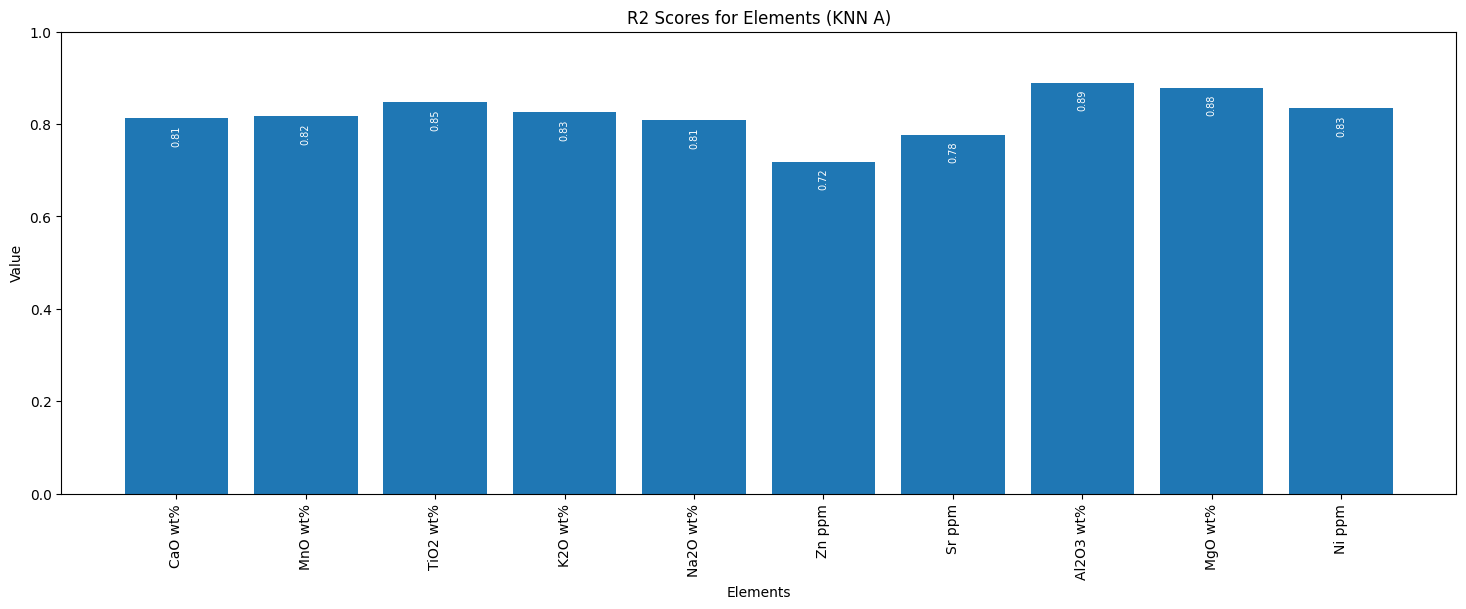

In [26]:
SaveResults(AggregateFolds(results_kfold_knn_A), f"Results/", "RandomForest_KFold_KNN_A")
ReportResults(AggregateFolds(results_kfold_knn_A))
DisplayElementScoresGraph(AggregateFolds(results_kfold_knn_A), metric="r2", title="R2 Scores for Elements (KNN A)")

### Results Comparison

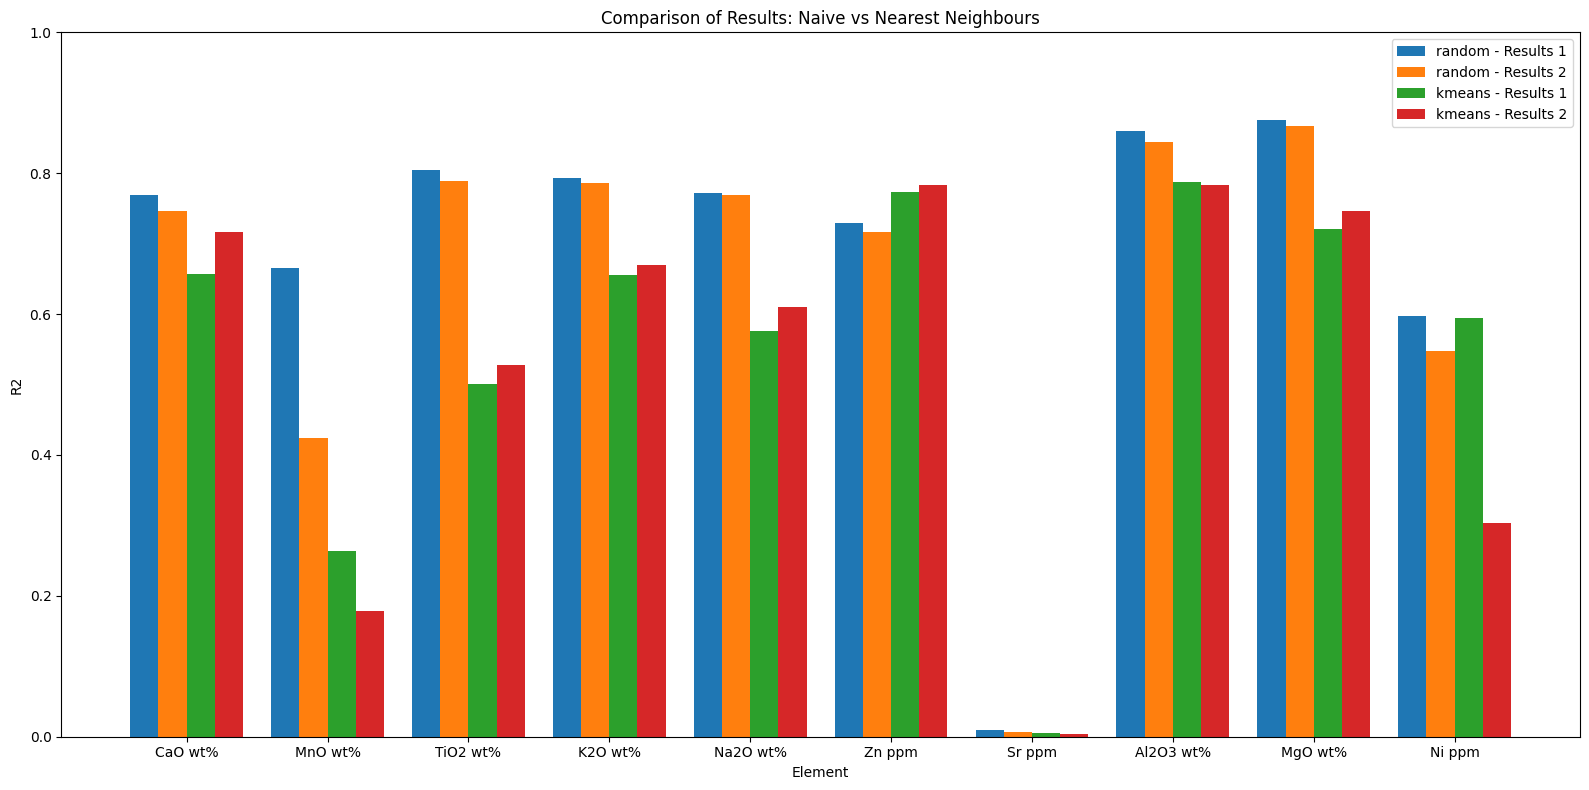

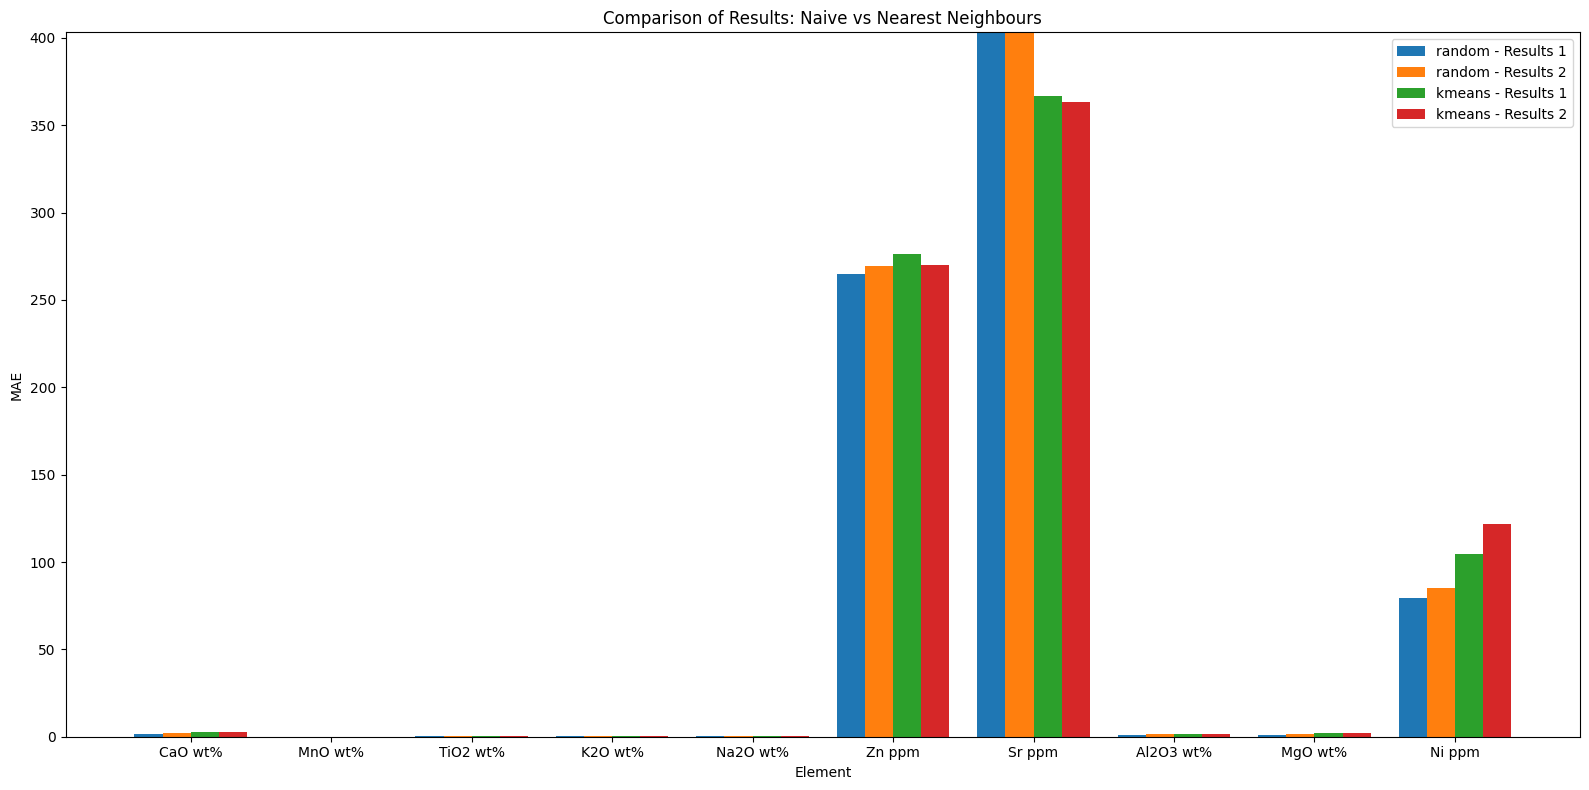

In [77]:
#Plots the desired methods and elements on a graph for both results side by side
def CompareResultsOnGraph(results1: dict, results2: dict, methods: list[str], elements: list[str], metric="r2", title="Comparison of Results"):
    datasets = methods
    x = np.arange(len(elements))
    width = 0.8 / len(datasets)

    fig, ax = plt.subplots(figsize=(16, 8))

    for i, dataset in enumerate(datasets):
        values1 = [results1[dataset][element][metric] for element in elements]
        values2 = [results2[dataset][element][metric] for element in elements]

        offset = (i - (len(datasets) - 1) / 2) * width

        ax.bar(x + offset - width/4, values1, width/2, label=f"{dataset} - Results 1")
        ax.bar(x + offset + width/4, values2, width/2, label=f"{dataset} - Results 2")

    ax.set_xlabel("Element")
    ax.set_ylabel(metric.upper())
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(elements)
    ax.set_ylim(0, max(max(values1 + values2) * 1.1, 1))  # Set y-limit to slightly above the max value
    ax.legend()

    plt.tight_layout()
    plt.show()
    
CompareResultsOnGraph(results_naive, results, methods=["random", "kmeans"], elements=list(splits.keys()), metric="r2", title="Comparison of Results: Naive vs Nearest Neighbours")
CompareResultsOnGraph(results_naive, results, methods=["random", "kmeans"], elements=list(splits.keys()), metric="mae", title="Comparison of Results: Naive vs Nearest Neighbours")

In [76]:
json.dump(results, open("Results/results_nn_1.json", "w"), indent=4)
json.dump(results_naive, open("Results/results_naive.json", "w"), indent=4)

C:\Users\salva\AppData\Local\Temp\ipykernel_22816\3251083851.py:1: ResourceWarning: unclosed file <_io.TextIOWrapper name='Results/results_nn_1.json' mode='w' encoding='cp1252'>
  json.dump(results, open("Results/results_nn_1.json", "w"), indent=4)
C:\Users\salva\AppData\Local\Temp\ipykernel_22816\3251083851.py:2: ResourceWarning: unclosed file <_io.TextIOWrapper name='Results/results_naive.json' mode='w' encoding='cp1252'>
  json.dump(results_naive, open("Results/results_naive.json", "w"), indent=4)


### Random Forest + Full Nearest Neighbours

### Random Forest + Masked Full Nearest Neighbours